<a href="https://colab.research.google.com/github/aerau05/air_fryers/blob/main/demand_estimation_pricing_analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Author: Neil Parikh and Nick Larson, Date: 05/04/2026, AI Statement: Generative AI was utilized for debugging and organization purposes. The ideas presented are my own (Ideas are as my own as much as they can be given that we were given an example).
# Instructions:
## Demand Estimation and Market Analysis: Air Fryers

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.


In [1]:
#importing packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# Coefficients table (r^2) from part 2, instead of loading from the csv
df = pd.read_csv('air_fryers_clean_brand_year.csv')

feature_cols = [
    'compact_share',
    'dual_basket_share',
    'oven_style_share',
    'rotisserie_share',
    'window_share',
] # defining characteristics needed

y = df['log_brand_share'] #dependent variable (target)

# one-hot encoded dummy variable for categorical data
brand_dummies = pd.get_dummies(df['brand'], prefix='brand', drop_first=True, dtype=int)
year_dummies  = pd.get_dummies(df['year'].astype(str), prefix='year', drop_first=True, dtype=int)

X = pd.concat(
    [df[['avg_price', 'avg_rating'] + feature_cols], brand_dummies, year_dummies],
    axis=1,
) # final feature matrix X by concatenating continuous varibales, features, and dummies

model = LinearRegression()
model.fit(X, y) # fit linear reg

predicted_log_share = model.predict(X)
r2 = r2_score(y, predicted_log_share) #predictions and calcualte R-squared to evaluate model fit

coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_,
}) #store in dataframe

print('R-squared:', r2)
coef_table

R-squared: 0.763453950091436


,feature,coefficient
0,avg_price,-0.037668
1,avg_rating,0.287517
2,compact_share,9.815304
3,dual_basket_share,-9.509686
4,oven_style_share,1.941774
5,rotisserie_share,-5.674054
6,window_share,12.880298
7,brand_cosori,2.551946
8,brand_cuisinart,6.422436
9,brand_dash,0.176655


Analysis: Avg Price coefficient is negative (-.037668) which confirms what the assignment instructions stated. Also, the r2 value is pretty solid.

**Next Part:**

"
Compute:
- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.
"

In [3]:
# Chart with unit cost, markup, average profit, profit change over time, calculated from price_coef.
# Creates the answers for question 2 (see below)
price_coef = coef_table.loc[coef_table['feature'] == 'avg_price', 'coefficient'].iloc[0] #extract specific price coefficient
print('Estimated price coefficient:', price_coef)

results = df.copy()
results['predicted_log_share'] = predicted_log_share
results['demand_slope'] = price_coef * results['brand_share'] * (1 - results['brand_share']) #slope via logit derivative
results['unit_cost'] = results['avg_price'] + results['brand_share'] / results['demand_slope'] #infer marginal cost
results['markup'] = results['avg_price'] - results['unit_cost'] #price - cost
results['average_profit'] = results['brand_share'] * results['markup'] #share-weighted profit index
results['profit_derivative'] = (            #calculate profit derivative (used to verify pricing condition)
    results['demand_slope'] * results['markup'] + results['brand_share']
)

print(results[['unit_cost', 'markup', 'average_profit', 'profit_derivative']].describe())

Estimated price coefficient: -0.03766765298429383
        unit_cost     markup  average_profit  profit_derivative
count   50.000000  50.000000       50.000000       5.000000e+01
mean    93.102239  29.703894        3.155916       2.985893e-18
std     51.696080   2.615822        2.615822       1.753363e-17
min     22.002913  26.567362        0.019385      -2.775558e-17
25%     53.159061  27.952365        1.404387      -3.903128e-18
50%     70.038270  28.813285        2.265308       0.000000e+00
75%    123.561937  30.956852        4.408875       1.214306e-17
max    199.729962  37.507010       10.959033       5.551115e-17


In [4]:
#grouping results by brand, and finding average unit costs and markup over years.
results[[
    'brand',
    'markup',
    'unit_cost',
    'average_profit',
]].groupby('brand').mean() #mean for each metric above

,markup,unit_cost,average_profit
brand,,,
chefman,29.368946,61.569466,2.820968
cosori,27.984628,86.283321,1.436651
cuisinart,29.050974,194.896119,2.502997
dash,29.542349,27.936578,2.994372
gowise usa,31.153741,56.301040,4.605764
instant_pot,32.558234,71.903119,6.010256
ninja,32.854071,112.488470,6.306093
nuwave,27.970835,109.053549,1.422858
oster,27.226315,161.804969,0.678338


**Q1: What are the average unit costs and markups for each brand over the years?**

See the table directly above this for both metrics. The analysis reveals a clear division in average unit costs, with budget brands operating at significantly lower costs than premium brands like Cuisinart (\$195) and Oster (\$162). However, markups remain remarkably consistent across the market, generally clustering tightly between \$27 and \$37 regardless of the product's underlying unit cost.

**Q2: Are any inferred unit costs negative? If so, what might that mean?**

As seen in the table generated just before the table above this box, none of the unit costs are negative.

It would not make sense to have a negative unit cost, there is no such thing as a negatively priced object. If there was a negative unit cost, that would probably be indicative that something went wrong in data parsing, or in a calculation performed. Specifically, a negative inferred cost occurs if the estimated demand curve is too inelastic, meaning the model failed to accurately capture how consumers truly respond to price changes.

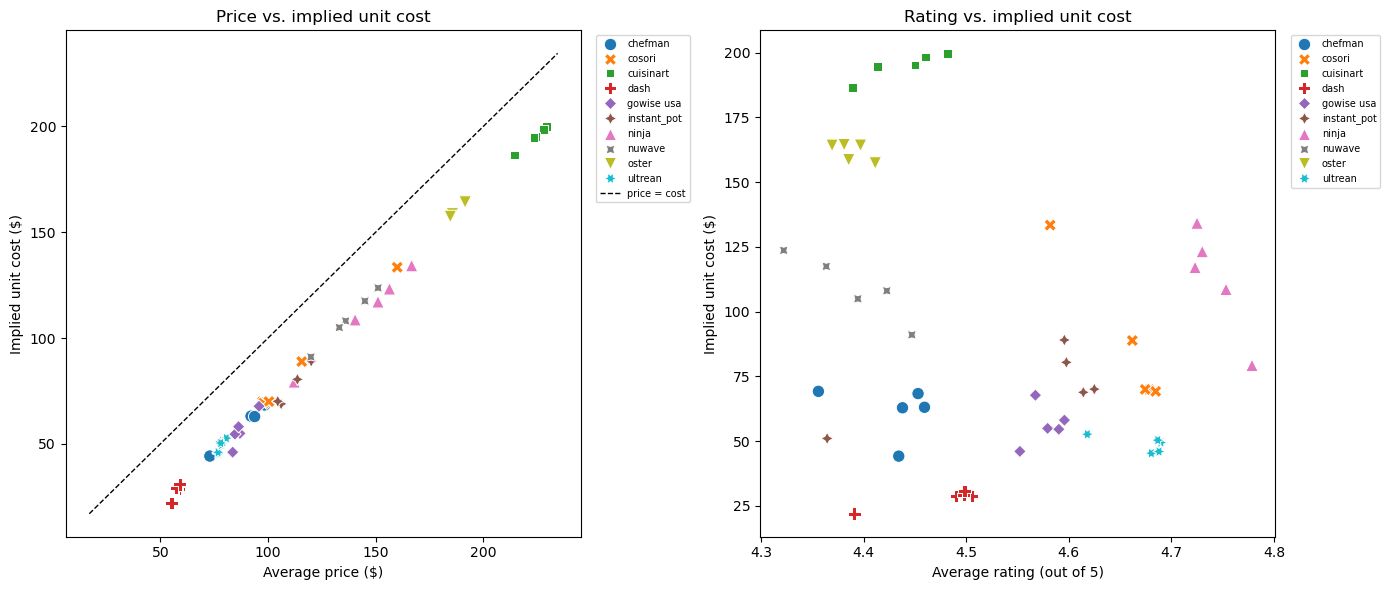

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#plot 1: compare retail price to marginal cost calculated already
sns.scatterplot(
    data=results, x='avg_price', y='unit_cost',
    hue='brand', style='brand', s=80, ax=axes[0]
)
lim = [results[['avg_price', 'unit_cost']].min().min() - 5,
       results[['avg_price', 'unit_cost']].max().max() + 5]
axes[0].plot(lim, lim, 'k--', linewidth=1, label='price = cost') #adds 45 degree line
axes[0].set_xlabel('Average price ($)')
axes[0].set_ylabel('Implied unit cost ($)')
axes[0].set_title('Price vs. implied unit cost')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

#plot 2: evalute if higher production costs correlate with better reviews
sns.scatterplot(
    data=results, x='avg_rating', y='unit_cost',
    hue='brand', style='brand', s=80, ax=axes[1]
)
axes[1].set_xlabel('Average rating (out of 5)')
axes[1].set_ylabel('Implied unit cost ($)')
axes[1].set_title('Rating vs. implied unit cost')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

**Q3a — Which brands have the highest average unit costs? How do unit costs and ratings compare?**

Cuisinart (`$195`) and Oster (`$162`) have the highest implied unit costs, followed by Ninja (`$112`) and NuWave (`$109`) - which perfectly mirrors the ordering of average price. When comparing unit costs to average ratings, there is a weak positive correlation with higher-cost brands tend to sit slightly higher on the rating axis. However, because all brands are tightly clustered between 4.3 and 4.8 stars, the substantial cost premium of a brand like Cuisinart over a budget brand like Dash buys only a marginal fraction of a star in average consumer satisfaction.

It’s pretty interesting to see that the cost hierarchy perfectly follows the price hierarchy. Usually, you might expect one brand to be "overpriced" (high price, low cost) or another to be a "steal" (low price, high cost), but this market is surprisingly logical. The fact that the highest-cost brands struggle to break away from the pack in terms of ratings suggests that there’s a "ceiling" on satisfaction. Basically, once an air fryer works well, there’s only so much more a consumer will care about, regardless of whether the internal components cost $50 or $150 to make.

**Q3b — Do expensive products have higher satisfaction?**

Weakly yes. The price vs. unit cost scatter shows that higher-priced brands carry substantially higher implied costs, and the rating vs. unit cost scatter shows that higher-cost brands tend to earn slightly better ratings. Following that chain, more expensive air fryers do tend to be rated a bit higher on average. That said, the effect is small — ratings are compressed into a 4.3–4.8 band across all brands, so no brand stands out as clearly more satisfying based on price alone. All points fall below the 45° reference line in the first scatter, confirming that every brand prices above its inferred cost.

Looking at how tight that star-rating gap is, it seems like the market has reached a point where even the cheaper models are doing a "good enough" job for most people. Even though the premium brands are clearly spending a lot more to build their machines, customers aren't necessarily rewarding them with way higher praise. It feels like once you hit a certain baseline of quality, spending another $100 only buys you a slightly "nicer" feel rather than a significantly "better" air fryer. For a brand like Cuisinart, this is a tough spot to be in—it’s hard to justify those high production costs when a budget brand like Dash is sitting just a fraction of a star behind them in satisfaction.

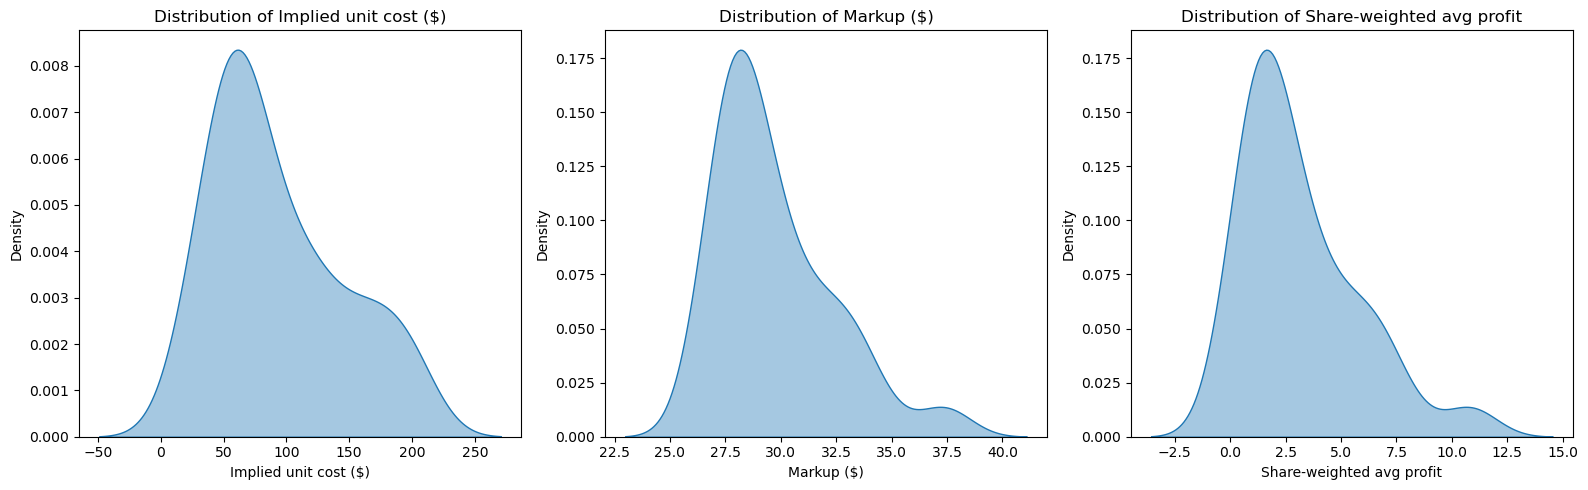

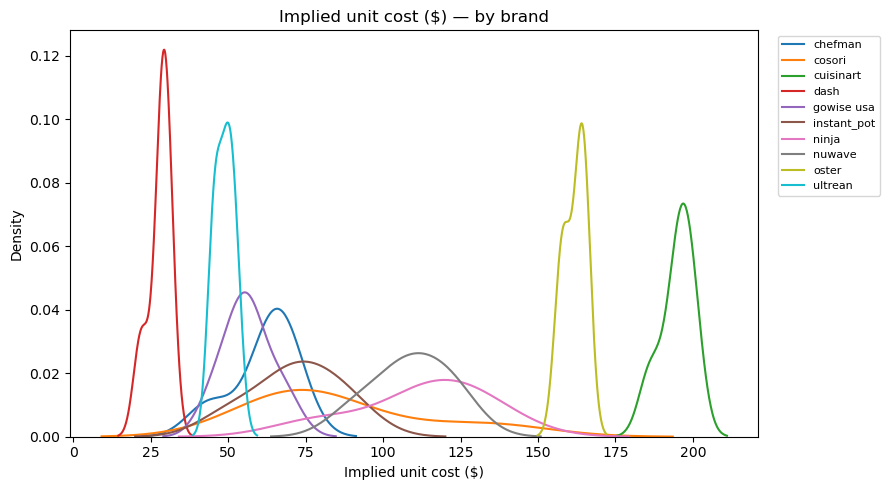

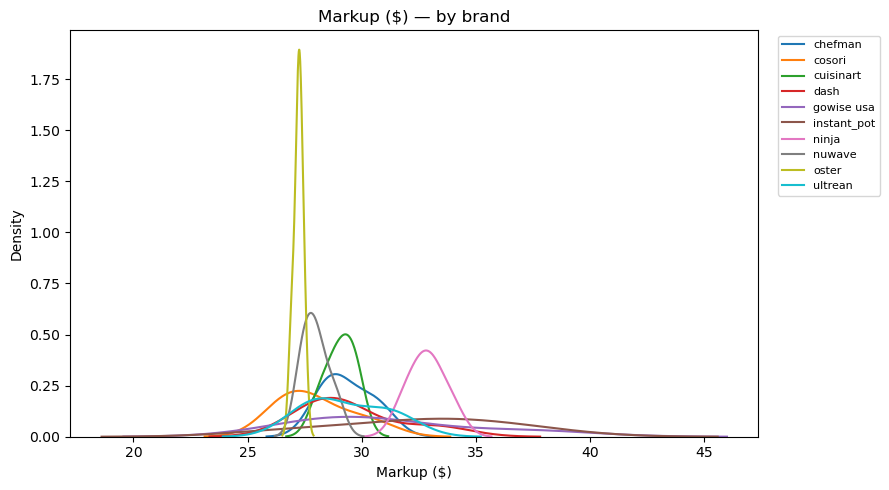

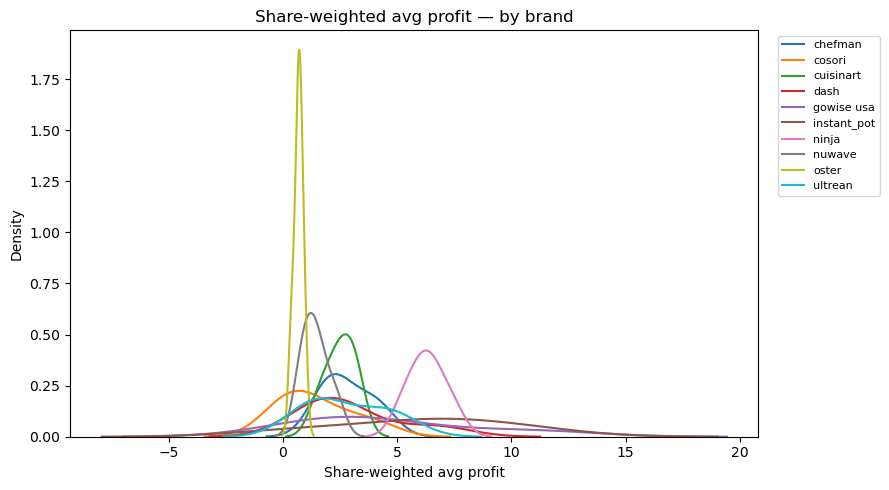

In [ ]:
metrics = [
    ('unit_cost',      'Implied unit cost ($)'),
    ('markup',         'Markup ($)'),
    ('average_profit', 'Share-weighted avg profit'),
]   #defining metrics and their corresponding display labels for plotting

# 1x3 subplot for overall market distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (col, label) in zip(axes, metrics):
    sns.kdeplot(data=results, x=col, ax=ax, fill=True, alpha=0.4) #plot aggregate KDE for each metric
    ax.set_xlabel(label)
    ax.set_title(f'Distribution of {label}')
plt.tight_layout()
plt.show()

# generate individual plots broken down by brand
for col, label in metrics:
    fig, ax = plt.subplots(figsize=(9, 5))
    for brand, grp in results.groupby('brand'):
        if grp[col].std() > 0:
            sns.kdeplot(data=grp, x=col, ax=ax, label=brand, fill=False) #plot distribution if values vary
        else:
            ax.axvline(grp[col].iloc[0], linestyle='--', label=brand) #vertical line if value is constant
    ax.set_xlabel(label)
    ax.set_title(f'{label} — by brand')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8) #legend outside plot
    plt.tight_layout()
    plt.show()

**Q4 — Looking at the kernel density plots, what do the distributions of unit costs, markups, and average profit look like?**

**Unit costs:** Slightly bimodal overall — a cluster of low-cost brands (Dash, Ultrean, Chefman, GoWISE USA) and a separate cluster of high-cost premium brands (Cuisinart, Oster, NuWave). The by-brand KDEs show each brand's cost is relatively stable over the five years, indicating that production technologies and supply chains for these appliances are firmly established with very little fluctuation.

**Markups:** Much more concentrated than unit costs. All brands show positive markups roughly in the $27–$37 range. The distribution has a slight right tail driven by GoWISE USA and Ninja in their strongest years, which suggests a rigid industry standard where all brands target a specific dollar margin to cover the overhead  regardless of their retail price tier.

**Average profit (share-weighted):** Right-skewed — most brand-year observations cluster at low values because either share or markup is small, but a handful of observations (GoWISE USA and Ninja in peak years) pull the tail upward. The by-brand plots make clear that high profit requires both a large share *and* a healthy markup. This proves that market share and volume are the true drivers of profitability.


In [ ]:
#rank brands by highest average share-weighted profit
results[[
    'brand',
    'average_profit',
]].groupby('brand').mean().sort_values('average_profit', ascending=False)

,average_profit
brand,
ninja,6.306093
instant_pot,6.010256
gowise usa,4.605764
dash,2.994372
chefman,2.820968
ultrean,2.780864
cuisinart,2.502997
cosori,1.436651
nuwave,1.422858


**Q5 — Which brands have the highest share-weighted average profit?**

Ninja (6.31) and Instant Pot (6.01) lead the market in average share-weighted profit, followed by GoWISE USA (4.61). The data reveals exactly why these brands dominate by successfully combining a meaningful market share with the highest actual markups in the entire industry (Ninja at \$32.85, Instant Pot at \$32.56, and GoWISE at \$31.15).

On the other hand, while a premium brand like Cuisinart has the highest overall price and unit cost, its actual markup is strictly average (\$29.05). Combining this with a small market share, this drags its profit index down to roughly 2.50. At the bottom of the market, Oster yields the lowest average profit (0.68) because it suffers from the lowest markup in the group (\$27.23) alongside a low market share, despite being the second most expensive appliance to produce.


**Q6 / Extra — Comparison to provided benchmarks**

The air fryer dataset does not include `provided_markup`, `provided_marginal_cost`, or `provided_profit` columns. Those benchmark columns exist only in the Bluetooth speakers file, where lecture-provided estimates were included for validation. No direct comparison is possible here.

In [ ]:
results.to_csv('air_fryers_pricing_results.csv', index=False)
print('Saved air_fryers_pricing_results.csv')

Saved air_fryers_pricing_results.csv
